In [96]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
#loading data
df = pd.read_csv("Sample Marketing Media Data.csv")
df.head()

,CampaignID,Platform,CampaignType,StartDate,EndDate,Spend,Impressions,Clicks,Conversions,Currency
0,c0037457-0184-4803-9840-fccb2446ecee,Facebook,Awareness,2024-12-23,2025-03-12,36416.92,856125,19518.0,8375,EUR
1,903374bf-c812-46e6-ac77-cfc8b38e5adb,Facebook,Engagement,2024-10-10,2025-04-05,38643.75,354064,49079.0,5230,EUR
2,48f3531c-4fb7-43bb-8408-c04c6f446806,TV - Channel A,Awareness,2025-02-01,2025-03-09,16990.69,387116,3210.0,424,USD
3,fda834ea-c74d-425c-adbf-859c037d9752,Google,Engagement,2025-02-11,2025-03-07,4514.52,302504,19986.0,5635,USD
4,f23db306-47ca-4779-b7c9-7da8d1db32f8,Google,Awareness,2024-11-15,2025-03-25,20658.44,677282,15091.0,8954,USD


In [98]:
df.shape

(205, 10)

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CampaignID    205 non-null    object 
 1   Platform      205 non-null    object 
 2   CampaignType  205 non-null    object 
 3   StartDate     205 non-null    object 
 4   EndDate       205 non-null    object 
 5   Spend         202 non-null    float64
 6   Impressions   205 non-null    int64  
 7   Clicks        200 non-null    float64
 8   Conversions   205 non-null    int64  
 9   Currency      205 non-null    object 
dtypes: float64(2), int64(2), object(6)
memory usage: 16.1+ KB


In [100]:
df.describe()

,Spend,Impressions,Clicks,Conversions
count,202.000000,205.000000,200.000000,205.000000
mean,24485.138416,490923.136585,24734.740000,4961.263415
std,14598.351675,285942.858826,14166.749829,2788.898190
min,1065.660000,12098.000000,631.000000,135.000000
25%,12709.215000,279152.000000,12481.000000,2522.000000
50%,22272.430000,466582.000000,24414.500000,5115.000000
75%,37341.290000,722885.000000,36431.250000,7309.000000
max,49722.840000,993306.000000,49865.000000,9933.000000


In [101]:
#changing data type of date from object to datetime
df["StartDate"] = pd.to_datetime(df["StartDate"])
df["EndDate"] = pd.to_datetime(df["EndDate"])

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   CampaignID    205 non-null    object        
 1   Platform      205 non-null    object        
 2   CampaignType  205 non-null    object        
 3   StartDate     205 non-null    datetime64[ns]
 4   EndDate       205 non-null    datetime64[ns]
 5   Spend         202 non-null    float64       
 6   Impressions   205 non-null    int64         
 7   Clicks        200 non-null    float64       
 8   Conversions   205 non-null    int64         
 9   Currency      205 non-null    object        
dtypes: datetime64[ns](2), float64(2), int64(2), object(4)
memory usage: 16.1+ KB


In [103]:
#checking null values
df.isnull().sum()

CampaignID      0
Platform        0
CampaignType    0
StartDate       0
EndDate         0
Spend           3
Impressions     0
Clicks          5
Conversions     0
Currency        0
dtype: int64

In [104]:
#filling null values with median of platform categories
df["Spend"] = df.groupby("Platform")["Spend"].transform(lambda x: x.fillna(x.median()))
df["Clicks"] = df.groupby("Platform")["Clicks"].transform(lambda x: x.fillna(x.median()))

In [105]:
df.isnull().sum()

CampaignID      0
Platform        0
CampaignType    0
StartDate       0
EndDate         0
Spend           0
Impressions     0
Clicks          0
Conversions     0
Currency        0
dtype: int64

In [106]:
#Checking duplicates by CampaignID
df.duplicated(subset="CampaignID").sum()

5

In [107]:
#inspecting duplicate campaigns
duplicates = df[df.duplicated(subset="CampaignID", keep=False)]
duplicates.sort_values("CampaignID")

,CampaignID,Platform,CampaignType,StartDate,EndDate,Spend,Impressions,Clicks,Conversions,Currency
2,48f3531c-4fb7-43bb-8408-c04c6f446806,TV - Channel A,Awareness,2025-02-01,2025-03-09,16990.69,387116,3210.0,424,USD
202,48f3531c-4fb7-43bb-8408-c04c6f446806,TV - Channel A,Awareness,2025-02-01,2025-03-09,16990.69,387116,3210.0,424,USD
75,c1378e75-627b-4de7-9ae4-45e08b1dc2f8,Instagram,Engagement,2024-12-24,2025-03-18,38815.34,807930,6556.0,5115,EUR
132,c1378e75-627b-4de7-9ae4-45e08b1dc2f8,Instagram,Engagement,2024-12-24,2025-03-18,38815.34,807930,6556.0,5115,EUR
73,cbf1f93c-a1d3-4772-8101-1c5bf110397a,Instagram,Engagement,2025-01-14,2025-03-08,45374.50,345399,46060.0,1540,GBP
131,cbf1f93c-a1d3-4772-8101-1c5bf110397a,Instagram,Engagement,2025-01-14,2025-03-08,45374.50,345399,46060.0,1540,GBP
4,f23db306-47ca-4779-b7c9-7da8d1db32f8,Google,Awareness,2024-11-15,2025-03-25,20658.44,677282,15091.0,8954,USD
204,f23db306-47ca-4779-b7c9-7da8d1db32f8,Google,Awareness,2024-11-15,2025-03-25,20658.44,677282,15091.0,8954,USD
3,fda834ea-c74d-425c-adbf-859c037d9752,Google,Engagement,2025-02-11,2025-03-07,4514.52,302504,19986.0,5635,USD
203,fda834ea-c74d-425c-adbf-859c037d9752,Google,Engagement,2025-02-11,2025-03-07,4514.52,302504,19986.0,5635,USD


In [108]:
#Checking if rows are exact duplicates
df[df.duplicated()]

,CampaignID,Platform,CampaignType,StartDate,EndDate,Spend,Impressions,Clicks,Conversions,Currency
131,cbf1f93c-a1d3-4772-8101-1c5bf110397a,Instagram,Engagement,2025-01-14,2025-03-08,45374.50,345399,46060.0,1540,GBP
132,c1378e75-627b-4de7-9ae4-45e08b1dc2f8,Instagram,Engagement,2024-12-24,2025-03-18,38815.34,807930,6556.0,5115,EUR
202,48f3531c-4fb7-43bb-8408-c04c6f446806,TV - Channel A,Awareness,2025-02-01,2025-03-09,16990.69,387116,3210.0,424,USD
203,fda834ea-c74d-425c-adbf-859c037d9752,Google,Engagement,2025-02-11,2025-03-07,4514.52,302504,19986.0,5635,USD
204,f23db306-47ca-4779-b7c9-7da8d1db32f8,Google,Awareness,2024-11-15,2025-03-25,20658.44,677282,15091.0,8954,USD


In [109]:
#dropping only exact duplicate rows
df = df.drop_duplicates()

In [110]:
#validation check: Logic: Impressions ≥ Clicks ≥ Conversions
df[df["Clicks"] > df["Impressions"]]

,CampaignID,Platform,CampaignType,StartDate,EndDate,Spend,Impressions,Clicks,Conversions,Currency
55,80e97f74-c307-49a4-88a1-33abdd55daaf,Facebook,Retention,2024-12-31,2025-04-05,15179.54,37536,49346.0,7605,EUR
149,ed2ee36f-c211-4eda-b1e7-ea9b2f6570d7,YouTube,Conversion,2025-02-08,2025-04-02,13881.23,12098,47663.0,2486,USD


In [111]:
df[df["Conversions"] > df["Clicks"]]

,CampaignID,Platform,CampaignType,StartDate,EndDate,Spend,Impressions,Clicks,Conversions,Currency
38,09c64c1d-00f2-4603-8295-1fe052c553b5,Facebook,Engagement,2024-11-29,2025-03-16,20748.180,161255,1145.0,4299,GBP
62,8d7f7ba5-72e6-416e-a671-0ad2c1b5468a,Amazon,Retention,2024-12-14,2025-03-12,27418.390,700411,6130.0,8070,USD
84,d5cf2dc4-eb1c-4ba4-9b9e-42d02b0c9fdd,Google,Retention,2025-01-22,2025-03-30,41127.970,345006,1791.0,2681,USD
91,5b8c4949-1068-41d3-a33d-9c54f30459cc,TV - Channel A,Engagement,2024-11-21,2025-03-28,21489.600,188528,6302.0,7463,USD
101,5567a84c-1480-4037-939a-4bb0d62b68d4,Amazon,Engagement,2024-12-11,2025-03-20,46499.930,770154,4707.0,5818,USD
115,e0db22d3-29e3-46ad-b9dd-c4775a220eb2,TV - Channel A,Retention,2024-11-13,2025-03-23,13032.960,775836,3098.0,5227,USD
119,6fa00319-e54c-40de-ae79-7a9218b7f1a2,Instagram,Awareness,2024-11-19,2025-03-22,12680.130,116068,1261.0,9810,USD
120,fff83cec-2c05-4870-8d34-bcd7b7ed75b4,Shopify,Conversion,2025-03-06,2025-03-29,48725.680,884909,8302.0,8504,EUR
123,1ca5a2f5-ecf1-40e6-86f1-49c70c15a575,TV - Channel B,Awareness,2024-12-19,2025-03-26,8566.240,893407,4539.0,8872,EUR
177,e1680205-3c0a-44de-8e24-5cf78e33dcab,TV - Channel A,Awareness,2025-02-15,2025-03-22,48414.300,950707,631.0,1406,EUR


In [112]:
#considering only valid rows for further operation
df = df[df["Clicks"] <= df["Impressions"]]
df = df[df["Conversions"] <= df["Clicks"]]

In [113]:
#saving cleaned dataset
df.to_csv("cleaned_marketing_media_data.csv", index=False)

In [114]:
#campaign distribution by platforms
df["Platform"].value_counts()

Platform
Google            31
Facebook          26
TV - Channel A    26
TV - Channel B    25
Shopify           22
Instagram         21
YouTube           19
Amazon            14
Name: count, dtype: int64

In [115]:
#Total Spend by Platform
platform_spend = df.groupby("Platform")["Spend"].sum().sort_values(ascending=False)

platform_spend

Platform
TV - Channel A    812134.090
Google            766271.820
Facebook          634591.110
Instagram         553863.260
Shopify           544836.380
TV - Channel B    532137.540
YouTube           400262.495
Amazon            257284.110
Name: Spend, dtype: float64

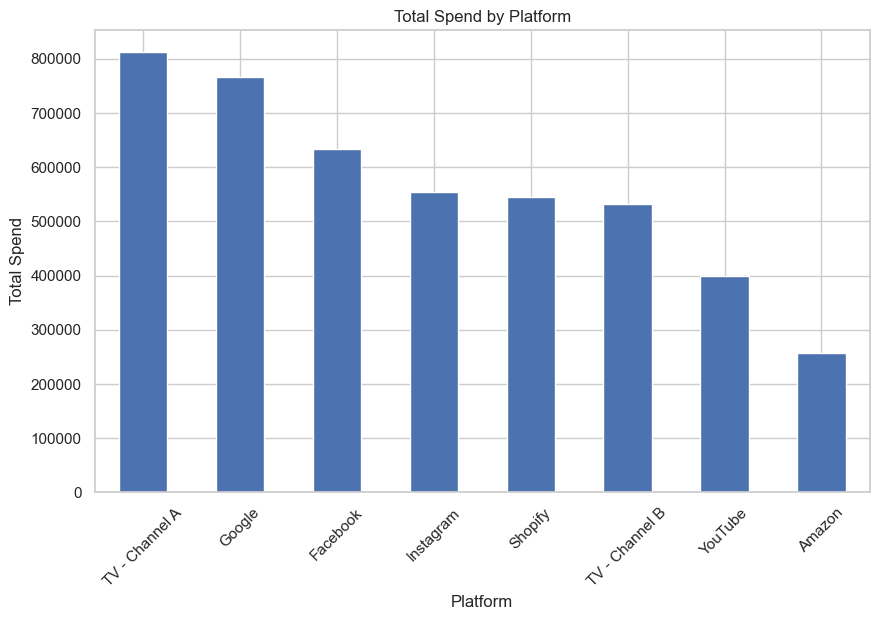

In [116]:
#Total Spend by Platform plot

plt.figure(figsize=(10,6))

platform_spend.plot(kind="bar")

plt.title("Total Spend by Platform")
plt.xlabel("Platform")
plt.ylabel("Total Spend")
plt.xticks(rotation=45)

plt.show()

In [117]:
#Total Conversions by Platform
platform_conv = df.groupby("Platform")["Conversions"].sum().sort_values(ascending=False)

platform_conv

Platform
Google            160981
TV - Channel A    140949
Facebook          136111
Shopify           112475
Instagram         106144
TV - Channel B     96644
YouTube            78399
Amazon             72713
Name: Conversions, dtype: int64

In [118]:
#KPI Calculations

platform_kpi = df.groupby("Platform").agg({
    "Spend":"sum",
    "Impressions":"sum",
    "Clicks":"sum",
    "Conversions":"sum"
})
platform_kpi

,Spend,Impressions,Clicks,Conversions
Platform,,,,
Amazon,257284.110,6137278,415085.0,72713
Facebook,634591.110,12260151,633929.0,136111
Google,766271.820,15516825,733426.0,160981
Instagram,553863.260,11287051,664339.0,106144
Shopify,544836.380,9814351,601229.0,112475
TV - Channel A,812134.090,11339940,652907.0,140949
TV - Channel B,532137.540,15297641,667445.0,96644
YouTube,400262.495,8923893,482916.0,78399


In [119]:
platform_kpi["CPM"] = (platform_kpi["Spend"] / platform_kpi["Impressions"]) * 1000

In [120]:
platform_kpi["CPM"] = (platform_kpi["Spend"] / platform_kpi["Impressions"]) * 1000

In [121]:
platform_kpi["CPV"] = platform_kpi["Spend"] / platform_kpi["Impressions"]

In [122]:
platform_kpi["ConversionRate"] = platform_kpi["Conversions"] / platform_kpi["Clicks"]

In [123]:
platform_kpi["ROAS"] = platform_kpi["Conversions"] / platform_kpi["Spend"]

In [124]:
platform_kpi["CPA"] = platform_kpi["Spend"] / platform_kpi["Conversions"]

In [125]:
platform_kpi.sort_values("ConversionRate", ascending=False)

,Spend,Impressions,Clicks,Conversions,CPM,CPV,ConversionRate,ROAS,CPA
Platform,,,,,,,,,
Google,766271.820,15516825,733426.0,160981,49.383287,0.049383,0.219492,0.210083,4.760014
TV - Channel A,812134.090,11339940,652907.0,140949,71.617142,0.071617,0.215879,0.173554,5.761900
Facebook,634591.110,12260151,633929.0,136111,51.760464,0.051760,0.214710,0.214486,4.662306
Shopify,544836.380,9814351,601229.0,112475,55.514255,0.055514,0.187075,0.206438,4.844067
Amazon,257284.110,6137278,415085.0,72713,41.921534,0.041922,0.175176,0.282618,3.538351
YouTube,400262.495,8923893,482916.0,78399,44.852902,0.044853,0.162345,0.195869,5.105454
Instagram,553863.260,11287051,664339.0,106144,49.070679,0.049071,0.159774,0.191643,5.218036
TV - Channel B,532137.540,15297641,667445.0,96644,34.785595,0.034786,0.144797,0.181615,5.506162


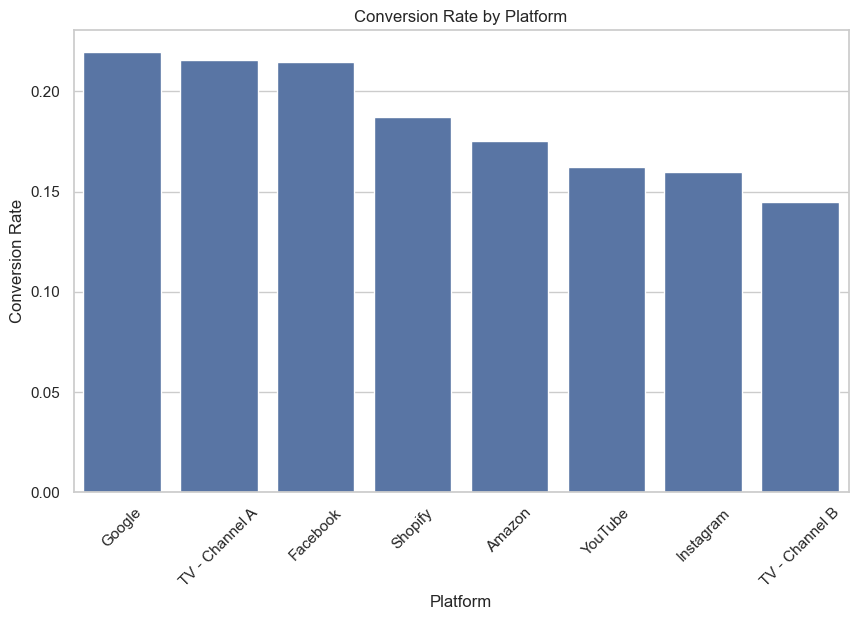

In [126]:
# Coversion rate by platform plot

plt.figure(figsize=(10,6))

sns.barplot(
    x=platform_kpi.sort_values("ConversionRate", ascending=False).index,
    y=platform_kpi.sort_values("ConversionRate", ascending=False)["ConversionRate"]
)

plt.title("Conversion Rate by Platform")
plt.xlabel("Platform")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)

plt.show()

In [127]:
#Campaign Type Analysis

campaign_perf = df.groupby("CampaignType").agg({
    "Spend":"sum",
    "Clicks":"sum",
    "Conversions":"sum"
})

campaign_perf["ConversionRate"] = campaign_perf["Conversions"] / campaign_perf["Clicks"]

campaign_perf.sort_values("ConversionRate", ascending=False)

,Spend,Clicks,Conversions,ConversionRate
CampaignType,,,,
Retention,1255650.100,1119279.0,260440,0.232686
Awareness,1023734.760,1115848.5,210554,0.188694
Engagement,1067212.080,1210268.5,214604,0.177319
Conversion,1154783.865,1405880.0,218818,0.155645


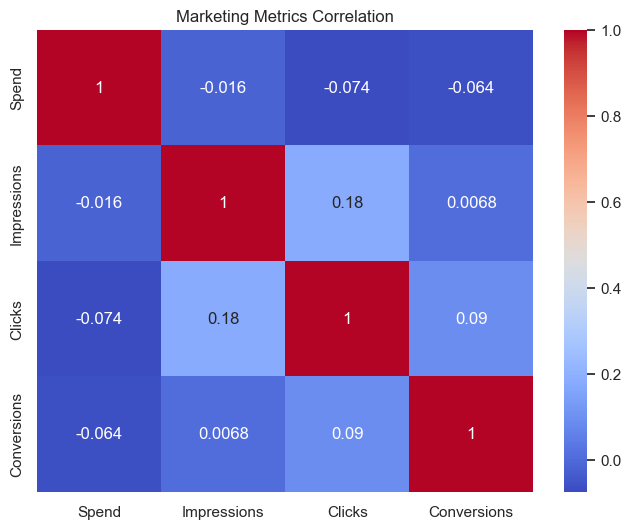

In [128]:
# corellation analysis
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Spend","Impressions","Clicks","Conversions"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Marketing Metrics Correlation")
plt.show()